In [59]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [60]:
df = pd.read_csv('data/cleaned/veltix_cleaned.csv')
df

,sku_id,product_category,week_id,sales_qty,inventory_begin,inventory_end,receipts,lead_time_days,unit_cost,holding_cost_rate
0,SH-005,Smart Home,2023-W28,24.0,180.0,156,0,0,69.09,0.25
1,WR-007,Wearables,2024-W12,35.0,466.0,431,0,0,65.79,0.30
2,AU-010,Audio,2024-W17,33.0,1776.0,1743,0,0,57.05,0.28
3,WR-005,Wearables,2023-W52,180.0,492.0,312,0,0,131.41,0.30
4,MA-003,Mobile Accessories,2023-W07,166.0,1659.0,1493,0,0,5.65,0.25
...,...,...,...,...,...,...,...,...,...,...
7608,CP-004,Computer Peripherals,2024-W27,115.0,778.0,663,0,0,44.48,0.25
7609,CP-005,Computer Peripherals,2024-W35,61.0,551.0,490,0,0,25.49,0.25
7610,MA-006,Mobile Accessories,2024-W29,133.0,1155.0,1022,0,0,19.49,0.25
7611,SH-009,Smart Home,2025-W12,8.0,325.0,317,0,0,28.70,0.25


In [61]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7613 entries, 0 to 7612
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sku_id             7613 non-null   str    
 1   product_category   7613 non-null   str    
 2   week_id            7613 non-null   str    
 3   sales_qty          7613 non-null   float64
 4   inventory_begin    7613 non-null   float64
 5   inventory_end      7613 non-null   int64  
 6   receipts           7613 non-null   int64  
 7   lead_time_days     7613 non-null   int64  
 8   unit_cost          7613 non-null   float64
 9   holding_cost_rate  7613 non-null   float64
dtypes: float64(4), int64(3), str(3)
memory usage: 594.9 KB


## 1. How is inventory turnover distributed across SKUs, and which ones drag capital efficiency?


In [62]:
# Compute turnover per SKU across the 156-week (~3-year) window.
df['avg_inv'] = (df['inventory_begin'] + df['inventory_end']) / 2

turnover = (
    df.groupby('sku_id')['sales_qty'].sum()
    / df.groupby('sku_id')['avg_inv'].mean()
    / 3
).rename('turnover')

turnover.sort_values()

sku_id
MA-009    0.811076
SH-010    0.991993
MA-008    1.057681
SH-009    1.128270
CP-009    1.145927
CP-008    1.171168
CP-010    1.181429
MA-010    1.228395
AU-008    1.245978
AU-009    1.348010
WR-010    1.416149
AU-010    1.461553
WR-008    1.574538
WR-009    1.677069
SH-008    1.754314
WR-004    4.556651
WR-001    4.636157
SH-002    4.764940
MA-001    4.873350
AU-007    4.999338
CP-005    5.102353
SH-004    5.105757
SH-007    5.111663
MA-007    5.242546
MA-005    5.279834
SH-003    5.311587
CP-003    5.517140
CP-007    5.583408
CP-001    5.623745
SH-001    5.646274
CP-004    5.740041
MA-006    6.036240
CP-006    6.039504
AU-005    6.138822
MA-004    6.253038
WR-007    6.285036
MA-002    6.373601
WR-006    6.492232
WR-005    6.584111
AU-004    6.588459
AU-001    6.979505
CP-002    7.041267
AU-006    7.097937
SH-005    7.203016
MA-003    7.450225
WR-002    7.517795
WR-003    7.524749
AU-003    7.551817
SH-006    7.792202
AU-002    8.000927
Name: turnover, dtype: float64

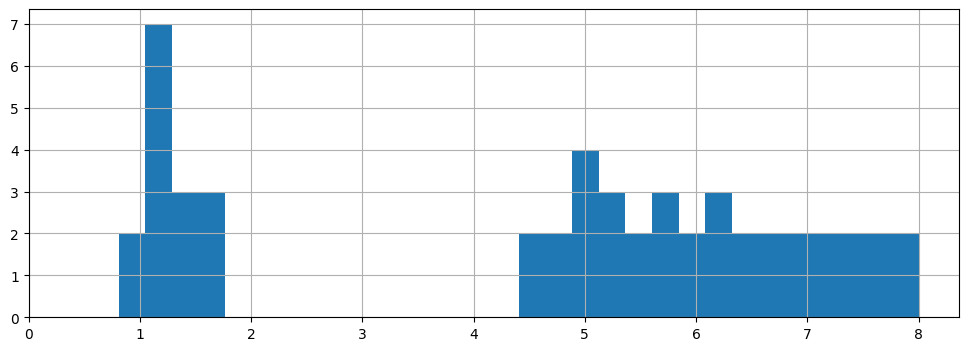

In [63]:
ax = turnover.hist(bins=30, figsize=(12, 4))
ax.set_xticks(range(0, 9, 1));

15 SKUs run at annualized turnover 0.81–1.75; the other 35 sit at 4.56–8.00. The distribution is cleanly bimodal with nothing in between, and the slow group is well under the 4.5–9 band usually cited for consumer electronics.

Every slow SKU ends in 008–010, three per category — a catalog-wide pattern rather than a category-level issue.

Worst case is MA-009 at 0.81 turns/year, about 15 months of stock on hand and roughly 18% of the industry floor. The 4.5 cutoff comes from that benchmark: consumer-electronics SKUs need to turn often enough to avoid obsolescence but rarely top 9.

## 2. How volatile is demand for the 15 low-turnover SKUs? Classify them into low/medium/high CV groups.

In [64]:
# Compute CV
stats = df.groupby('sku_id')['sales_qty'].agg(['mean', 'std'])
cv = stats['std'] / stats['mean']

# Filter low-turnover SKUs and bin them by CV
sku_to_category = df.groupby('sku_id')['product_category'].first()
low_turnover_skus = turnover[turnover < 1.8].index

# Split the 15 low-turnover SKUs into three CV buckets at 0 / 0.3 / 0.6
# Exposed as standalone Series so Section 3 can reuse it without recomputing
cv_group = pd.cut(
    cv.loc[low_turnover_skus],
    bins=[0, 0.3, 0.6, float('inf')],
    labels=['low_cv', 'mid_cv', 'high_cv']
)

pd.DataFrame({
    'category': sku_to_category.loc[low_turnover_skus],
    'cv': cv.loc[low_turnover_skus].round(2),
    'group': cv_group,
}).sort_values(['group', 'cv'])

,category,cv,group
sku_id,,,
MA-010,Mobile Accessories,0.14,low_cv
MA-008,Mobile Accessories,0.15,low_cv
MA-009,Mobile Accessories,0.15,low_cv
CP-009,Computer Peripherals,0.18,low_cv
CP-010,Computer Peripherals,0.18,low_cv
CP-008,Computer Peripherals,0.19,low_cv
SH-010,Smart Home,0.21,low_cv
SH-008,Smart Home,0.22,low_cv
SH-009,Smart Home,0.22,low_cv


The CV distribution splits the 15 slow movers into three distinct patterns of *how* they fail to sell.

**9 low-CV SKUs** (Mobile Accessories, Computer Peripherals, Smart Home; CV 0.14–0.22) sell at very stable but persistently weak volumes — steadily underselling. Demand is easy to forecast, so the problem isn't stocking policy; it's the product itself.

**3 mid-CV SKUs** (Audio; CV 0.50–0.56) show moderate swings, consistent with early-lifecycle behavior or mild seasonality.

**3 high-CV SKUs** (Wearables; CV 0.70–0.75) are highly irregular, with std exceeding 70% of mean — erratically underselling. Demand is hard to forecast, and the inventory pile-up likely stems from over-buffering against stockouts.

CV groups map cleanly onto product categories, reflecting that each category carries its own demand profile — a structure that will drive the safety-stock design in Section 3.

## 3. How do safety stock and holding cost trade off against service level across CV groups?

### Per-SKU demand and lead-time stats

In [65]:
# Demand stats: per-SKU weekly mean & std across all 156 weeks
demand_stats = df.groupby('sku_id')['sales_qty'].agg(mean_d='mean', std_d='std')

# Lead-time stats: lead_time_days is only populated on replenishment rows; other weeks are 0.
# Filter to receipt events before aggregating, otherwise the 0s drag the mean down.
# Divide the whole frame by 7 to convert days to weeks so L and σ_d (weekly) share units in the formula.
lt_stats = (
    df[df['lead_time_days'] > 0]
      .groupby('sku_id')['lead_time_days']
      .agg(mean_L='mean', std_L='std')
    / 7
)

# Merge into a single params DataFrame — all downstream SS / HC calcs hang off this.
params = demand_stats.join(lt_stats)
params.head()

,mean_d,std_d,mean_L,std_L
sku_id,,,,
AU-001,121.736842,65.722146,4.102041,0.820981
AU-002,176.282895,88.820111,4.100000,1.048540
AU-003,138.675325,71.148550,4.078341,0.914612
AU-004,76.267974,40.528256,4.009852,1.032229
AU-005,92.393548,46.975055,4.204762,0.785767


### Safety stock at three service levels

In [66]:
# Service level → Z-score lookup (inverse CDF of the normal distribution, standard SCM textbook values)
z_table = {0.85: 1.04, 0.90: 1.28, 0.95: 1.65}

# Full SS formula: SS = Z × √(L̄ × σ_d² + d̄² × σ_L²)
# The term inside √ is identical across service levels — compute it once and reuse.
ss_base = np.sqrt(
    params['mean_L'] * params['std_d']**2
    + params['mean_d']**2 * params['std_L']**2
)

# Compute SS once per service level; columns named ss_85 / ss_90 / ss_95.
for sl, z in z_table.items():
    params[f'ss_{int(sl * 100)}'] = z * ss_base

params.head()

,mean_d,std_d,mean_L,std_L,ss_85,ss_90,ss_95
sku_id,,,,,,,
AU-001,121.736842,65.722146,4.102041,0.820981,173.112614,213.061679,274.649821
AU-002,176.282895,88.820111,4.100000,1.048540,268.212511,330.107706,425.529465
AU-003,138.675325,71.148550,4.078341,0.914612,199.321994,245.319377,316.232009
AU-004,76.267974,40.528256,4.009852,1.032229,117.589598,144.725659,186.560420
AU-005,92.393548,46.975055,4.204762,0.785767,125.444812,154.393614,199.023019


### Weekly holding cost

In [67]:
# Per-SKU cost parameters are fixed, so .first() pulls one row.
params['unit_cost'] = df.groupby('sku_id')['unit_cost'].first()
params['holding_cost_rate'] = df.groupby('sku_id')['holding_cost_rate'].first()

# Weekly holding cost: HC = SS × unit_cost × (holding_cost_rate / 52)
# /52 amortizes the annualized rate back to a weekly basis to align with SS's weekly units.
weekly_rate = params['holding_cost_rate'] / 52
for sl in [85, 90, 95]:
    params[f'hc_{sl}'] = params[f'ss_{sl}'] * params['unit_cost'] * weekly_rate

params.head()

,mean_d,std_d,mean_L,std_L,ss_85,ss_90,ss_95,unit_cost,holding_cost_rate,hc_85,hc_90,hc_95
sku_id,,,,,,,,,,,,
AU-001,121.736842,65.722146,4.102041,0.820981,173.112614,213.061679,274.649821,43.01,0.28,40.091550,49.343446,63.606786
AU-002,176.282895,88.820111,4.100000,1.048540,268.212511,330.107706,425.529465,25.58,0.28,36.943179,45.468528,58.611774
AU-003,138.675325,71.148550,4.078341,0.914612,199.321994,245.319377,316.232009,52.28,0.28,56.110674,69.059292,89.021743
AU-004,76.267974,40.528256,4.009852,1.032229,117.589598,144.725659,186.560420,53.31,0.28,33.754546,41.544057,53.552886
AU-005,92.393548,46.975055,4.204762,0.785767,125.444812,154.393614,199.023019,16.42,0.28,11.091251,13.650771,17.596697


### Aggregate holding cost by CV group

In [68]:
# Take only the 15 low-turnover SKUs and attach the CV group label (indexes align, so assign auto-joins).
slow_params = params.loc[low_turnover_skus].assign(cv_group=cv_group)

# Average the weekly holding cost for each service level within each cv_group.
hc_cols = ['hc_85', 'hc_90', 'hc_95']
hc_by_group = (
    slow_params
    .groupby('cv_group', observed=True)[hc_cols]
    .mean()
    .round(2)
)
hc_by_group

,hc_85,hc_90,hc_95
cv_group,,,
low_cv,3.39,4.17,5.37
mid_cv,11.63,14.32,18.46
high_cv,21.09,25.96,33.46


### Service level vs holding cost

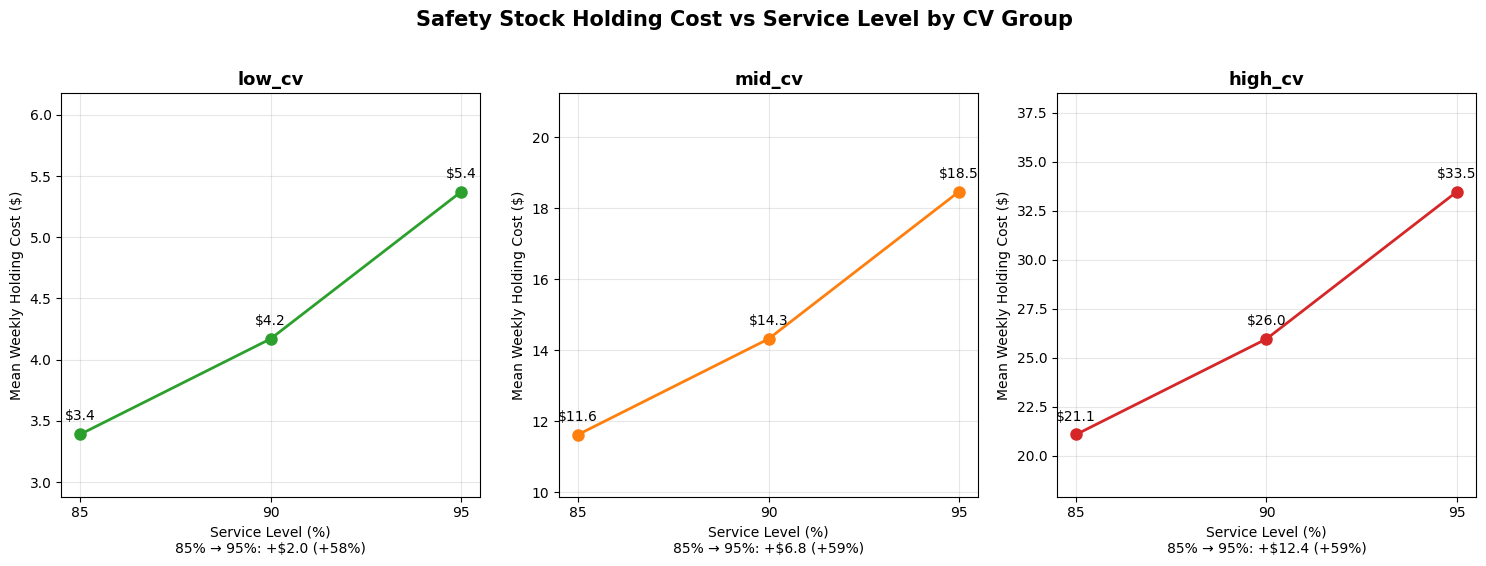

In [69]:
service_levels = [85, 90, 95]
hc_cols = [f'hc_{sl}' for sl in service_levels]
colors = {'low_cv': 'tab:green', 'mid_cv': 'tab:orange', 'high_cv': 'tab:red'}
groups = ['low_cv', 'mid_cv', 'high_cv']

fig, axes = plt.subplots(1, 3, figsize=(15, 5.5))

for ax, group in zip(axes, groups):
    values = hc_by_group.loc[group, hc_cols].values
    ax.plot(
        service_levels,
        values,
        marker='o',
        color=colors[group],
        linewidth=2,
        markersize=8,
    )
    
    # Annotate each point with its dollar value.
    for x, y in zip(service_levels, values):
        ax.annotate(
            f'${y:.1f}',
            xy=(x, y),
            xytext=(0, 10),
            textcoords='offset points',
            ha='center',
            fontsize=10,
        )
    
    # Compute the 85% → 95% increase.
    abs_change = values[-1] - values[0]
    pct_change = (values[-1] / values[0] - 1) * 100
    
    ax.set_title(group, fontsize=13, fontweight='bold')
    ax.set_xlabel(
        f'Service Level (%)\n85% → 95%: +${abs_change:.1f} (+{pct_change:.0f}%)',
        fontsize=10,
    )
    ax.set_ylabel('Mean Weekly Holding Cost ($)')
    ax.set_xticks(service_levels)
    ax.grid(alpha=0.3)
    
    ymin, ymax = values.min(), values.max()
    ax.set_ylim(ymin * 0.85, ymax * 1.15)

fig.suptitle(
    'Safety Stock Holding Cost vs Service Level by CV Group',
    fontsize=15, fontweight='bold', y=1.02
)
plt.tight_layout()
plt.show()

## Conclusion

Simulating safety stock and holding cost at different service levels across the 15 low-turnover SKUs produces three distinct cost curves, one per CV group. By construction the *relative* 85% → 95% uplift is identical across groups (~+59%, since SS scales linearly with Z); what differentiates the groups is **absolute level** — high_cv runs ~6× more expensive than low_cv at every service level.

Each group's demand pattern (Section 2) calls for a different trade-off — the cost gap above just determines where applying the wrong policy hurts most.

### Cost comparison at 95% service level

| Group | Weekly holding cost | vs low_cv | Pattern |
|---|---|---|---|
| low_cv (9 SKUs) | $5.4 | 1.0x | Stable underselling |
| mid_cv (3 SKUs) | $18.5 | 3.4x | Moderate volatility |
| high_cv (3 SKUs) | $33.5 | 6.2x | Irregular |

### Differentiated recommendations

**Low CV group (9 SKUs) — Mobile Accessories / CP / Smart Home**

If kept on the catalog, 95% service level is essentially free ($5.4/week incremental). But the prior question is whether to keep them at all — demand is easy to forecast yet persistently weak, so raising service level won't generate sales. The real lever is revisiting pricing, positioning, or planning a clearance/EOL.

**Mid CV group (3 SKUs) — Audio**

Set service level at 90% ($14.3/week) to balance cost and service. Pushing to 95% adds $4.2/week for limited stockout improvement. Monitor sales trend — if there's an upward inflection, revisit raising the service level.

**High CV group (3 SKUs) — Wearables**

Set service level between 85%–90% ($21–$26/week). Chasing 95% blindly pushes weekly cost to $33.5 (6.2× the low_cv group). These SKUs sell irregularly *and* poorly — rather than over-buffering, the priority should be improving demand forecasting or adopting a conservative stocking stance.

### Key takeaway

Different patterns of slow-moving inventory call for different service-level strategies. A uniform standard (e.g. "95% across the board") wastes significant holding cost on the high_cv group, while masking the opportunity to fix the underlying product problem in the low_cv group.